# Projet IA

## Loading Datasets Individualy

### Import libraries

In [43]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [44]:
df_employee = pd.read_csv(
    "./Data/employee_survey_data.csv",
    sep=",",
    header=0,
    names=["EmployeeID","EnvironmentSatisfaction","JobSatisfaction","WorkLifeBalance"]
)
df_general = pd.read_csv(
    "./Data/general_data.csv",
    sep=",",
    header=0,
    names=["Age","Attrition","BusinessTravel","Department","DistanceFromHome","Education","EducationField","EmployeeCount","EmployeeID","Gender","JobLevel","JobRole","MaritalStatus","MonthlyIncome","NumCompaniesWorked","Over18","PercentSalaryHike","StandardHours","StockOptionLevel","TotalWorkingYears","TrainingTimesLastYear","YearsAtCompany","YearsSinceLastPromotion","YearsWithCurrManager"]
)
df_manager = pd.read_csv(
    "./Data/manager_survey_data.csv",
    sep=",",
    header=0,
    names=["EmployeeID","JobInvolvement","PerformanceRating"]
)

# Impute missing numeric values with the median for each dataset
for df in [df_employee, df_general, df_manager]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

## Merge datasets into one unique dataframe

In [45]:
# Merge the three sources using EmployeeID as the key
# All datasets have 4410 unique IDs and no duplicates, so an inner join keeps the full population.
df_merged = df_general.merge(df_employee, on='EmployeeID', how='inner').merge(df_manager, on='EmployeeID', how='inner')
print('Merged dataframe shape:', df_merged.shape)
print('Unique EmployeeID count:', df_merged['EmployeeID'].nunique())
print('Duplicate EmployeeID rows:', df_merged.duplicated(subset=['EmployeeID']).sum())
print('\nMerged dataframe columns:')
print(df_merged.columns.tolist())

# Use the merged dataframe for subsequent preprocessing and analysis
# This keeps the dataset unified and preserves the employee and manager survey data.
df_general = df_merged.copy()

Merged dataframe shape: (4410, 29)
Unique EmployeeID count: 4410
Duplicate EmployeeID rows: 0

Merged dataframe columns:
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating']


### Informations about the merged dataset

In [46]:
print("-------------------- Merged Dataset --------------------")
print("-------------------- HEAD --------------------")
print(df_general.head())
print("-------------------- DESCRIBE --------------------")
print(df_general.describe())
print("-------------------- INFO --------------------")
print(df_general.info())
print("-------------------- Missing Values --------------------")
print(df_general.isnull().sum())
print("-------------------- Duplicates Values --------------------")
print(df_general.duplicated().sum())
print("---------------------------------------------------")

-------------------- Merged Dataset --------------------
-------------------- HEAD --------------------
   Age Attrition     BusinessTravel              Department  DistanceFromHome  \
0   51        No      Travel_Rarely                   Sales                 6   
1   31       Yes  Travel_Frequently  Research & Development                10   
2   32        No  Travel_Frequently  Research & Development                17   
3   38        No         Non-Travel  Research & Development                 2   
4   32        No      Travel_Rarely  Research & Development                10   

   Education EducationField  EmployeeCount  EmployeeID  Gender  ...  \
0          2  Life Sciences              1           1  Female  ...   
1          1  Life Sciences              1           2  Female  ...   
2          4          Other              1           3    Male  ...   
3          5  Life Sciences              1           4    Male  ...   
4          1        Medical              1           5

In [47]:
print("-------------------- Original Employees dataset --------------------")
print("-------------------- HEAD --------------------")
print(df_employee.head())
print("-------------------- DESCRIBE --------------------")
print(df_employee.describe())
print("-------------------- INFO --------------------")
print(df_employee.info())
print("-------------------- Missing Values --------------------")
print(df_employee.isnull().sum())
print("-------------------- Duplicates Values --------------------")
print(df_employee.duplicated().sum())
print("---------------------------------------------------")

-------------------- Original Employees dataset --------------------
-------------------- HEAD --------------------
   EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
0           1                      3.0              4.0              2.0
1           2                      3.0              2.0              4.0
2           3                      2.0              2.0              1.0
3           4                      4.0              4.0              3.0
4           5                      4.0              1.0              3.0
-------------------- DESCRIBE --------------------
        EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
count  4410.000000              4410.000000      4410.000000      4410.000000
mean   2205.500000                 2.725170         2.729478         2.763492
std    1273.201673                 1.089852         1.098904         0.703541
min       1.000000                 1.000000         1.000000         1.000000
25%  

In [48]:
print("-------------------- Managers --------------------")
print("-------------------- HEAD --------------------")
print(df_manager.head())
print("-------------------- DESCRIBE --------------------")
print(df_manager.describe())
print("-------------------- INFO --------------------")
print(df_manager.info())
print("-------------------- Missing Values --------------------")
print(df_manager.isnull().sum())
print("-------------------- Duplicates Values --------------------")
print(df_manager.duplicated().sum())
print("---------------------------------------------------")

-------------------- Managers --------------------
-------------------- HEAD --------------------
   EmployeeID  JobInvolvement  PerformanceRating
0           1               3                  3
1           2               2                  4
2           3               3                  3
3           4               2                  3
4           5               3                  3
-------------------- DESCRIBE --------------------
        EmployeeID  JobInvolvement  PerformanceRating
count  4410.000000     4410.000000        4410.000000
mean   2205.500000        2.729932           3.153741
std    1273.201673        0.711400           0.360742
min       1.000000        1.000000           3.000000
25%    1103.250000        2.000000           3.000000
50%    2205.500000        3.000000           3.000000
75%    3307.750000        3.000000           3.000000
max    4410.000000        4.000000           4.000000
-------------------- INFO --------------------
<class 'pandas.DataFrame

As we can see, the three dataframe are approximatly proper but we have to preprocess the df_general as it contains string data.

## Preprocessing of General

#### Drop the non RGPD columns

In [49]:
# DROP Gender and EmployeeID columns
drop_columns = [col for col in ['Gender', 'EmployeeID', 'Over18', 'MaritalStatus'] if col in df_general.columns]
if drop_columns:
    df_general = df_general.drop(columns=drop_columns)
    print(f'Dropped columns from df_general: {drop_columns}')
else:
    print('Columns already removed or not present')

Dropped columns from df_general: ['Gender', 'EmployeeID', 'Over18', 'MaritalStatus']


## Encoded string categories

In [ ]:
features_to_encode = ['BusinessTravel','Department',
                      'EducationField','JobRole'
]
encoded = pd.get_dummies(df_general[features_to_encode], drop_first=True)
print(encoded)

      Attrition_Yes  BusinessTravel_Travel_Frequently  \
0             False                             False   
1              True                              True   
2             False                              True   
3             False                             False   
4             False                             False   
...             ...                               ...   
4405          False                             False   
4406          False                             False   
4407          False                             False   
4408          False                             False   
4409          False                             False   

      BusinessTravel_Travel_Rarely  Department_Research & Development  \
0                             True                              False   
1                            False                               True   
2                            False                               True   
3                      

# Creating Integer variable

In [51]:
numeric_features = [
    "DistanceFromHome","Education","EmployeeCount","JobLevel","MonthlyIncome","NumCompaniesWorked",
    "PercentSalaryHike","StandardHours","StockOptionLevel","TotalWorkingYears","TrainingTimesLastYear","YearsAtCompany","YearsSinceLastPromotion","YearsWithCurrManager"
]

In [52]:
# Convert Attrition to binary: Yes -> 1, No -> 0
df_general['Attrition_num'] = df_general['Attrition'].map({'Yes': 1, 'No': 0})

# Define your target
multi_y = df_general['Attrition_num']

### Correlation matrice

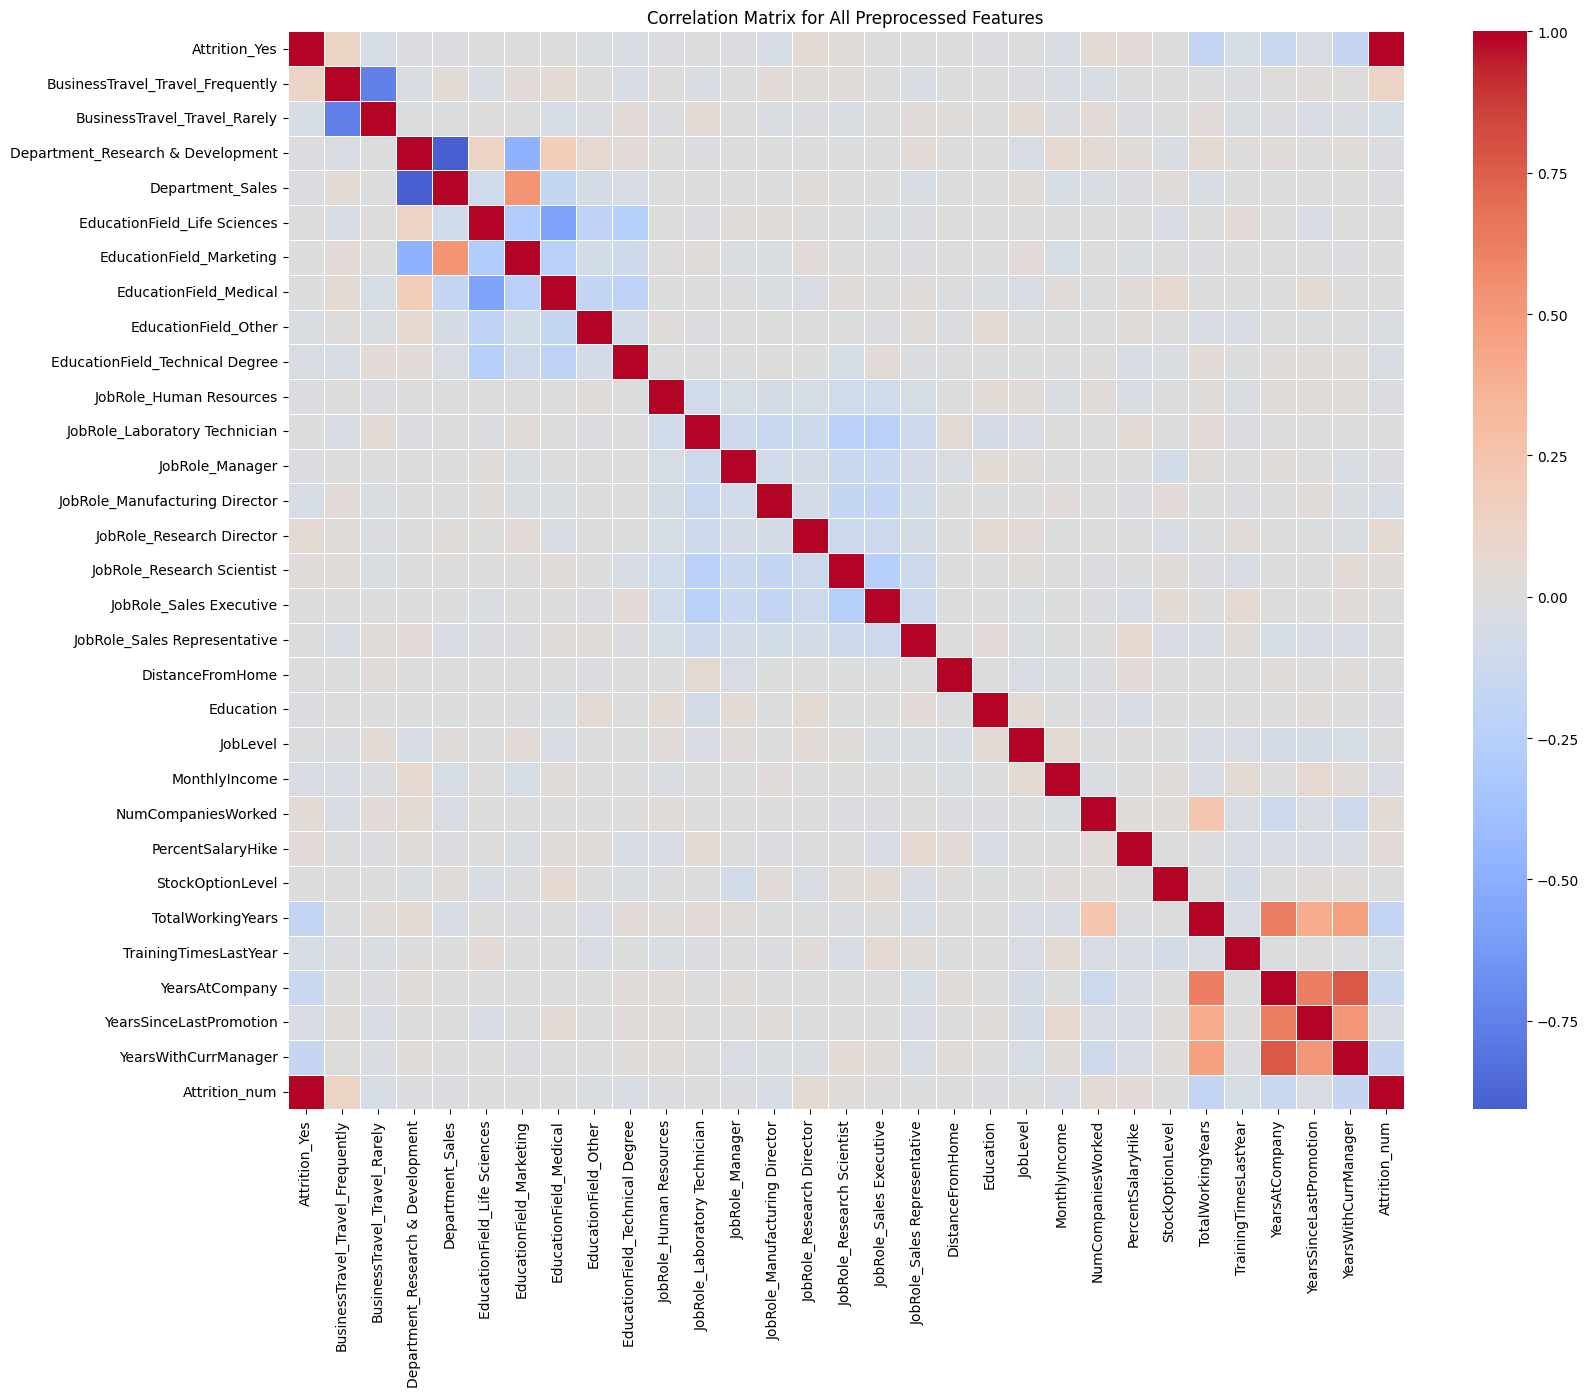

Strongest correlations with Attrition after preprocessing:
Attrition_Yes                       1.000000
TotalWorkingYears                   0.170162
YearsWithCurrManager                0.156199
YearsAtCompany                      0.134392
BusinessTravel_Travel_Frequently    0.115143
JobRole_Research Director           0.049760
BusinessTravel_Travel_Rarely        0.049538
TrainingTimesLastYear               0.049431
JobRole_Manufacturing Director      0.045770
NumCompaniesWorked                  0.042064
Name: Attrition_num, dtype: float64


In [53]:
# Compute correlation matrix using encoded features and integer numeric features
corr_data = pd.concat([encoded, df_general[numeric_features]], axis=1)
if 'Attrition_num' in df_general.columns:
    corr_data['Attrition_num'] = df_general['Attrition_num']
else:
    corr_data['Attrition_num'] = df_general['Attrition'].map({'Yes': 1, 'No': 0})

# Remove constant columns before computing correlation
corr_data = corr_data.loc[:, corr_data.nunique(dropna=True) > 1]

corr = corr_data.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix for All Preprocessed Features')
plt.show()

# Show the strongest correlations with Attrition
attrition_corr = corr['Attrition_num'].drop('Attrition_num')
print('Strongest correlations with Attrition after preprocessing:')
print(attrition_corr.abs().sort_values(ascending=False).head(10))

## Logistic Regression Curves

Top features used for logistic regression: ['Attrition_Yes', 'TotalWorkingYears']


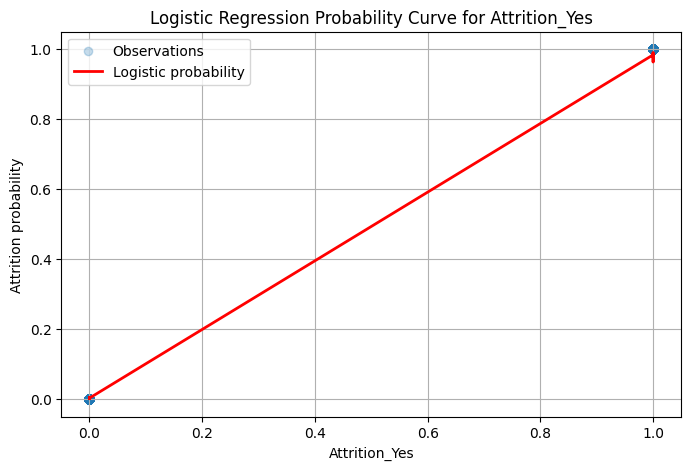

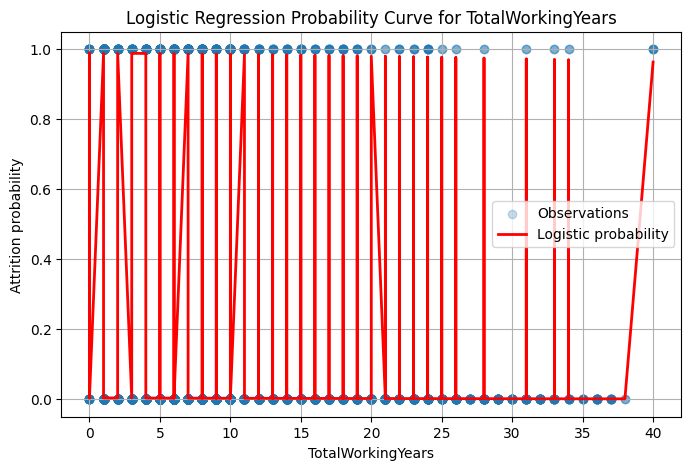

/app/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


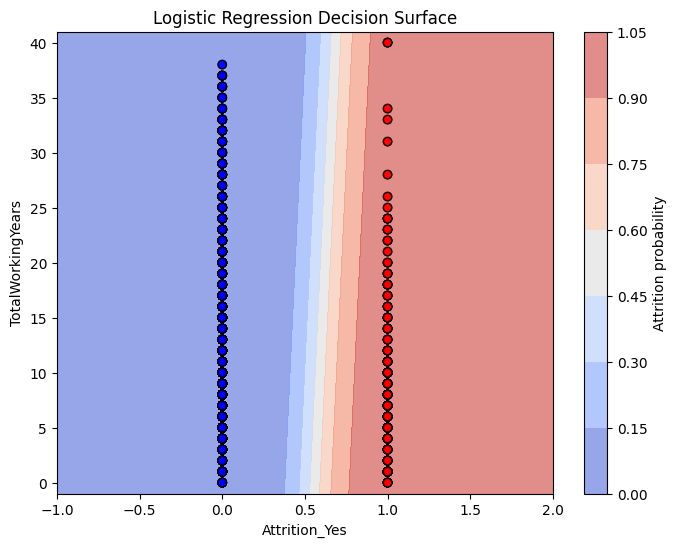

In [54]:
# Train a logistic regression model on the two most correlated features
top_features = attrition_corr.abs().sort_values(ascending=False).head(2).index.tolist()
print('Top features used for logistic regression:', top_features)

X_log = corr_data[top_features]
y_log = corr_data['Attrition_num']
clf_log = LogisticRegression(max_iter=500)
clf_log.fit(X_log, y_log)

# Plot probability curve for each top feature separately
for feature in top_features:
    plt.figure(figsize=(8, 5))
    idx = X_log[feature].sort_values().index
    values = X_log.loc[idx, feature].values
    probs = clf_log.predict_proba(X_log.loc[idx])[:, 1]
    plt.scatter(X_log[feature], y_log, alpha=0.25, label='Observations')
    plt.plot(values, probs, color='red', linewidth=2, label='Logistic probability')
    plt.title(f'Logistic Regression Probability Curve for {feature}')
    plt.xlabel(feature)
    plt.ylabel('Attrition probability')
    plt.legend()
    plt.grid(True)
    plt.show()

# If both features are numeric, show decision boundary in 2D
if len(top_features) == 2:
    feature_x, feature_y = top_features
    x_min, x_max = X_log[feature_x].min() - 1, X_log[feature_x].max() + 1
    y_min, y_max = X_log[feature_y].min() - 1, X_log[feature_y].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs_grid = clf_log.predict_proba(grid)[:, 1].reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(xx, yy, probs_grid, cmap='coolwarm', alpha=0.6)
    plt.scatter(X_log[feature_x], X_log[feature_y], c=y_log, cmap='bwr', edgecolor='k', alpha=0.6)
    plt.colorbar(contour, label='Attrition probability')
    plt.title('Logistic Regression Decision Surface')
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.show()

# Preparing the Dataset

In [55]:
train_set = encoded.join(df_general[numeric_features])

# Splitting the Dataset

In [56]:
train_X, test_X,train_Y, test_Y = train_test_split(train_set, multi_y, test_size=0.2, random_state=1337)

## Creating a validation set

In [57]:
multi_train_X, multi_val_X, multi_train_Y, multi_val_Y = train_test_split(train_X, train_Y, test_size=0.3, random_state=1337)

## Modèle et évaluation comparative

In [58]:
# Compare several classifiers to select the best model
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Random Forest': RandomForestClassifier(random_state=1337),
    'Gradient Boosting': GradientBoostingClassifier(random_state=1337)
}

results = []
for name, model in models.items():
    model.fit(multi_train_X, multi_train_Y)
    preds = model.predict(multi_val_X)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(multi_val_Y, preds),
        'Precision': precision_score(multi_val_Y, preds, average='weighted', zero_division=0),
        'Recall': recall_score(multi_val_Y, preds, average='weighted', zero_division=0),
        'F1': f1_score(multi_val_Y, preds, average='weighted', zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by='F1', ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]['Model']
print(f"\nBest model by F1 score: {best_model_name}")

# Keep the best model for later evaluation
best_model = models[best_model_name]

/app/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision  Recall   F1
0  Logistic Regression       1.0        1.0     1.0  1.0
1        Random Forest       1.0        1.0     1.0  1.0
2    Gradient Boosting       1.0        1.0     1.0  1.0

Best model by F1 score: Logistic Regression


In [59]:
# Use the selected best classifier from the comparison
rf_model_multi = best_model

Validation Set Evaluation:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


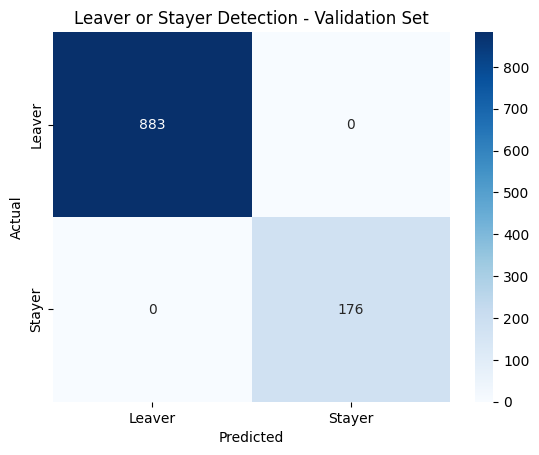

Classification Report for Validation Set:
              precision    recall  f1-score   support

      Leaver       1.00      1.00      1.00       883
      Stayer       1.00      1.00      1.00       176

    accuracy                           1.00      1059
   macro avg       1.00      1.00      1.00      1059
weighted avg       1.00      1.00      1.00      1059



In [60]:
# Predict and evaluate the model on the validation set
multi_predictions = rf_model_multi.predict(multi_val_X)
accuracy = accuracy_score(multi_val_Y, multi_predictions)
precision = precision_score(multi_val_Y, multi_predictions, average='weighted')
recall = recall_score(multi_val_Y, multi_predictions, average='weighted')
f1 = f1_score(multi_val_Y, multi_predictions, average='weighted')
print(f"Validation Set Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix for Validation Set
conf_matrix = confusion_matrix(multi_val_Y, multi_predictions)
class_labels = ['Leaver', 'Stayer']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Leaver or Stayer Detection - Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Validation Set
print("Classification Report for Validation Set:")
print(classification_report(multi_val_Y, multi_predictions, target_names=class_labels))


Test Set Evaluation:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


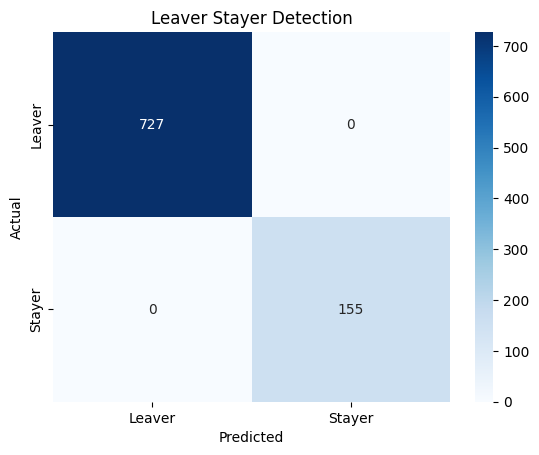

Classification Report for Test Set:
              precision    recall  f1-score   support

      Leaver       1.00      1.00      1.00       727
      Stayer       1.00      1.00      1.00       155

    accuracy                           1.00       882
   macro avg       1.00      1.00      1.00       882
weighted avg       1.00      1.00      1.00       882



In [61]:
# Final evaluation on the test set
test_multi_predictions = rf_model_multi.predict(test_X)
test_accuracy = accuracy_score(test_Y, test_multi_predictions)
test_precision = precision_score(test_Y, test_multi_predictions, average='weighted')
test_recall = recall_score(test_Y, test_multi_predictions, average='weighted')
test_f1 = f1_score(test_Y, test_multi_predictions, average='weighted')
print("\nTest Set Evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Confusion Matrix for Test Set
test_conf_matrix = confusion_matrix(test_Y, test_multi_predictions)
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Leaver Stayer Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Test Set
print("Classification Report for Test Set:")
print(classification_report(test_Y, test_multi_predictions, target_names=class_labels))